In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

df = pd.read_csv("neo.csv")
df.head

<bound method NDFrame.head of              id                 name  est_diameter_min  est_diameter_max  \
0       2162635  162635 (2000 SS164)          1.198271          2.679415   
1       2277475    277475 (2005 WK4)          0.265800          0.594347   
2       2512244   512244 (2015 YE18)          0.722030          1.614507   
3       3596030          (2012 BV13)          0.096506          0.215794   
4       3667127          (2014 GE35)          0.255009          0.570217   
...         ...                  ...               ...               ...   
90831   3763337           (2016 VX1)          0.026580          0.059435   
90832   3837603           (2019 AD3)          0.016771          0.037501   
90833  54017201           (2020 JP3)          0.031956          0.071456   
90834  54115824           (2021 CN5)          0.007321          0.016370   
90835  54205447           (2021 TW7)          0.039862          0.089133   

       relative_velocity  miss_distance orbiting_body  se

In [6]:
print(df.shape)
print(df.columns)
df.info()

(90836, 10)
Index(['id', 'name', 'est_diameter_min', 'est_diameter_max',
       'relative_velocity', 'miss_distance', 'orbiting_body', 'sentry_object',
       'absolute_magnitude', 'hazardous'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90836 entries, 0 to 90835
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  90836 non-null  int64  
 1   name                90836 non-null  object 
 2   est_diameter_min    90836 non-null  float64
 3   est_diameter_max    90836 non-null  float64
 4   relative_velocity   90836 non-null  float64
 5   miss_distance       90836 non-null  float64
 6   orbiting_body       90836 non-null  object 
 7   sentry_object       90836 non-null  bool   
 8   absolute_magnitude  90836 non-null  float64
 9   hazardous           90836 non-null  bool   
dtypes: bool(2), float64(5), int64(1), object(2)
memory usage: 5.7+ MB


In [10]:
df["hazardous"].value_counts()

hazardous
False    81996
True      8840
Name: count, dtype: int64

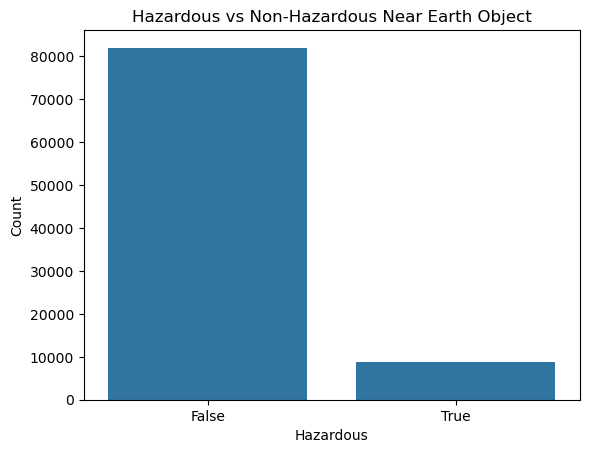

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="hazardous", data=df)

plt.title("Hazardous vs Non-Hazardous Near Earth Object")
plt.xlabel("Hazardous")
plt.ylabel("Count")
plt.show()

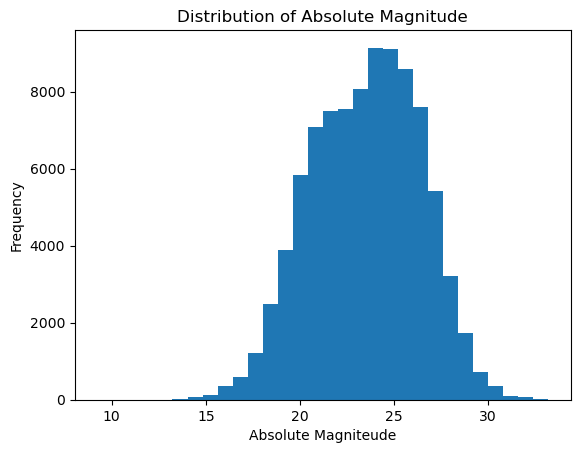

In [12]:
plt.hist(df["absolute_magnitude"], bins=30)
plt.title("Distribution of Absolute Magnitude")
plt.xlabel("Absolute Magniteude")
plt.ylabel("Frequency")
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

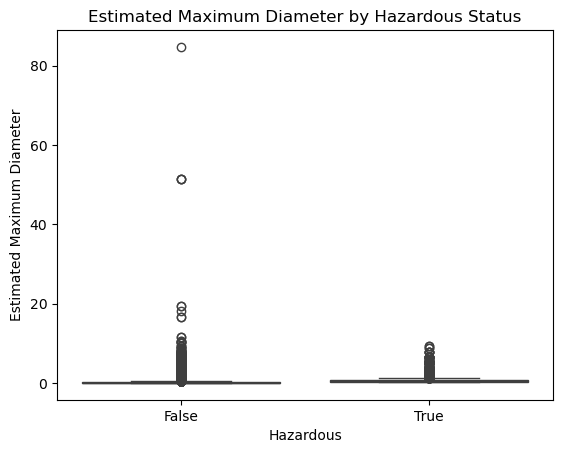

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt 

sns.boxplot(
    x="hazardous",
    y="est_diameter_max",
    data=df
)
plt.title("Estimated Maximum Diameter by Hazardous Status")
plt.xlabel("Hazardous")
plt.ylabel("Estimated Maximum Diameter")
plt.show


In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop("hazardous", axis=1)
y = df["hazardous"].astype(int)


X = X.drop(columns=["id", "name", "orbiting_body"], errors="ignore")


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [21]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000, random_state=42)

log_model.fit(X_train_scaled, y_train)

log_preds = log_model.predict(X_test_scaled)


In [22]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train_scaled, y_train)

knn_preds = knn_model.predict(X_test_scaled)

In [24]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print("Logistic Regression Accuracy:", accuracy_score(y_test, log_preds))
print("Logistic Regression Classification Report:")
print(classification_report(y_test, log_preds))

print("KNN Accuracy:", accuracy_score(y_test, knn_preds))
print("KNN Classification Report:")
print(classification_report(y_test, knn_preds))

Logistic Regression Accuracy: 0.9032915015411713
Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.99      0.95     16400
           1       0.52      0.08      0.14      1768

    accuracy                           0.90     18168
   macro avg       0.71      0.54      0.54     18168
weighted avg       0.87      0.90      0.87     18168

KNN Accuracy: 0.8991633641567591
KNN Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.96      0.95     16400
           1       0.47      0.30      0.37      1768

    accuracy                           0.90     18168
   macro avg       0.70      0.63      0.66     18168
weighted avg       0.88      0.90      0.89     18168

